In [1]:
%matplotlib inline
# Cell 1
import warnings
warnings.filterwarnings('ignore', message='pandas only supports SQLAlchemy')

import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image as IPImage
from scripts.shared import db_utils
from scripts.shared.db_utils import db_connect

conn = db_connect()
ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'demo'
OUT.mkdir(parents=True, exist_ok=True)
print('connected; output →', OUT)

connected; output → /Users/karlg/Documents/repos/_edops/output/edop/demo


In [2]:
# Cell 2
# ── WHG exploration SQL — run in DBeaver connected to whgv3beta ─────────────
# fclasses is character varying[] (not text[]) — cast accordingly.

explore_sql = """
-- Column types:
SELECT column_name, data_type, udt_name
FROM information_schema.columns
WHERE table_schema = 'public' AND table_name = 'places'
ORDER BY ordinal_position;

-- Sample with array-aware fclasses filter (P or S):
SELECT p.id, p.ccodes, p.fclasses,
       ST_AsText(pg.geom) AS geom_wkt
FROM public.places p
JOIN public.place_geom pg ON pg.place_id = p.id
WHERE ST_GeometryType(pg.geom) = 'ST_Point'
  AND p.fclasses && ARRAY['P','S']::varchar[]
LIMIT 10;
"""
print(explore_sql)


-- Column types:
SELECT column_name, data_type, udt_name
FROM information_schema.columns
WHERE table_schema = 'public' AND table_name = 'places'
ORDER BY ordinal_position;

-- Sample with array-aware fclasses filter (P or S):
SELECT p.id, p.ccodes, p.fclasses,
       ST_AsText(pg.geom) AS geom_wkt
FROM public.places p
JOIN public.place_geom pg ON pg.place_id = p.id
WHERE ST_GeometryType(pg.geom) = 'ST_Point'
  AND p.fclasses && ARRAY['P','S']::varchar[]
LIMIT 10;



In [3]:
# Cell 3
# ── Build SQL — run in DBeaver to create cedop.gaz.whg_NNNNN ────────────────
# fclasses is character varying[] — must cast comparison array to ::varchar[].
# DISTINCT ON (p.id) gives one POINT geom per place (stable by pg.id).

build_sql = """
-- Run in whgv3beta; export result as CSV for import to cedop.gaz.whg_NNNNN
SELECT DISTINCT ON (p.id)
    p.id          AS place_id,
    p.title       AS place_name,   -- adjust if column name differs
    p.ccodes,
    p.fclasses,
    ST_Y(pg.geom) AS lat,
    ST_X(pg.geom) AS lon
FROM public.places p
JOIN public.place_geom pg ON pg.place_id = p.id
WHERE ST_GeometryType(pg.geom) = 'ST_Point'
  AND p.fclasses && ARRAY['P','S']::varchar[]
ORDER BY p.id, pg.id;

-- After import, add spatial point geometry and index in cedop.gaz:
-- ALTER TABLE gaz.whg_NNNNN ADD COLUMN geom geometry(Point, 4326);
-- UPDATE gaz.whg_NNNNN SET geom = ST_SetSRID(ST_MakePoint(lon, lat), 4326);
-- CREATE INDEX ON gaz.whg_NNNNN USING GIST (geom);
"""
print(build_sql)


-- Run in whgv3beta; export result as CSV for import to cedop.gaz.whg_NNNNN
SELECT DISTINCT ON (p.id)
    p.id          AS place_id,
    p.title       AS place_name,   -- adjust if column name differs
    p.ccodes,
    p.fclasses,
    ST_Y(pg.geom) AS lat,
    ST_X(pg.geom) AS lon
FROM public.places p
JOIN public.place_geom pg ON pg.place_id = p.id
WHERE ST_GeometryType(pg.geom) = 'ST_Point'
  AND p.fclasses && ARRAY['P','S']::varchar[]
ORDER BY p.id, pg.id;

-- After import, add spatial point geometry and index in cedop.gaz:
-- ALTER TABLE gaz.whg_NNNNN ADD COLUMN geom geometry(Point, 4326);
-- UPDATE gaz.whg_NNNNN SET geom = ST_SetSRID(ST_MakePoint(lon, lat), 4326);
-- CREATE INDEX ON gaz.whg_NNNNN USING GIST (geom);



In [4]:
# Cell 4  — A1: Confirm local table + basin coverage
GAZ_TABLE = 'gaz.whg_gaz'

# Row count and fclasses breakdown
n_places = pd.read_sql(f'SELECT count(*) AS n FROM {GAZ_TABLE}', conn).iloc[0, 0]
print(f'Places in {GAZ_TABLE}: {n_places:,}')

fc = pd.read_sql(f"""
    SELECT fclasses, count(*) AS n
    FROM {GAZ_TABLE}
    GROUP BY fclasses
    ORDER BY n DESC
    LIMIT 20
""", conn)
print(fc.to_string(index=False))

 fclasses       n
      [P] 1460601
      [S]   51477
   [P, S]    2934
   [S, P]    1385
   [S, T]     118
   [A, P]     109
   [P, P]     108
   [P, T]      78
   [P, X]      56
   [L, P]      46
   [H, S]      34
   [S, X]      33
[A, P, S]      28
[P, S, T]      28
   [P, A]      22
   [H, P]      22
   [S, H]      21
   [N, P]      17
[L, P, S]      16
   [L, S]       6


In [5]:
# Cell 5  — A1: Load gazetteer with precomputed basin join; coverage stats
# hybas_id_l06 was precomputed via ST_Within UPDATE — simple equality select now.

gaz = pd.read_sql(f"""
    SELECT place_id, place_name, ccodes, fclasses, lat, lon, hybas_id_l06 AS hybas_id
    FROM {GAZ_TABLE}
    WHERE hybas_id_l06 IS NOT NULL
""", conn)

print(f'Rows loaded: {len(gaz):,}')
print(f'Unique basins with ≥1 place: {gaz["hybas_id"].nunique():,} of 16,397 L06 basins')
print(f'Unique places: {gaz["place_id"].nunique():,}')

per_basin = gaz.groupby('hybas_id').size()
print(f'\nPlaces per basin — median: {per_basin.median():.0f}, '
      f'p90: {per_basin.quantile(0.9):.0f}, max: {per_basin.max():,}')

Rows loaded: 1,508,492
Unique basins with ≥1 place: 10,799 of 16,397 L06 basins
Unique places: 1,508,492

Places per basin — median: 7, p90: 272, max: 13,947


In [6]:
# Cell 6  — Load all L06 scalar indices (vectorized numpy)
# Fetches monthly arrays from rev2 view; computes circular stats for all basins.

arr_sql = """
SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly
FROM public.v_basin06_persist_rev2
"""
raw = pd.read_sql(arr_sql, conn)
print(f'Basins loaded: {len(raw):,}')

# Convert list columns to (N, 12) numpy arrays
PRE = np.array(raw['pre_mm_monthly'].tolist(), dtype=float)   # (N, 12)
TMP = np.array(raw['tmp_dc_monthly'].tolist(), dtype=float)   # (N, 12)

THETA = np.array([2 * np.pi * m / 12 for m in range(12)])    # (12,)

def circ_concentration(W):
    """Vectorized circular concentration for (N, 12) weight matrix."""
    total = W.sum(axis=1, keepdims=True)
    total = np.where(total == 0, np.nan, total)
    Rx = (W * np.cos(THETA)).sum(axis=1) / total[:, 0]
    Ry = (W * np.sin(THETA)).sum(axis=1) / total[:, 0]
    conc  = np.sqrt(Rx**2 + Ry**2)
    angle = np.arctan2(Ry, Rx)
    peak  = (angle / (2 * np.pi) * 12) % 12
    return conc, angle, peak

pre_conc, pre_angle, pre_peak = circ_concentration(PRE)

# Shift temp by row-min before circular stats (avoids negative weights)
TMP_shifted = TMP - TMP.min(axis=1, keepdims=True)
tmp_conc, tmp_angle, tmp_peak = circ_concentration(TMP_shifted)

# Phase offset: circular distance between precip and temp peaks [0, 6] months
delta  = np.abs(pre_angle - tmp_angle)
delta  = np.minimum(delta, 2 * np.pi - delta)
offset = delta / (2 * np.pi) * 12

tmp_amp = TMP.max(axis=1) - TMP.min(axis=1)

basins = pd.DataFrame({
    'hybas_id':         raw['hybas_id'].values,
    'pre_concentration': pre_conc,
    'pre_peak_month':   pre_peak,
    'tmp_concentration': tmp_conc,
    'tmp_peak_month':   tmp_peak,
    'seas_phase_offset': offset,
    'tmp_seas_amp':     tmp_amp,
})
print(basins[['pre_concentration', 'seas_phase_offset', 'tmp_seas_amp']].describe().round(3).to_string())

Basins loaded: 16,397
       pre_concentration  seas_phase_offset  tmp_seas_amp
count          16338.000          16338.000     16397.000
mean               0.412              1.987        19.824
std                0.230              1.844        13.743
min                0.000              0.000         0.400
25%                0.223              0.542         8.100
50%                0.388              1.116        17.600
75%                0.596              3.463        30.200
max                1.000              6.000        61.600


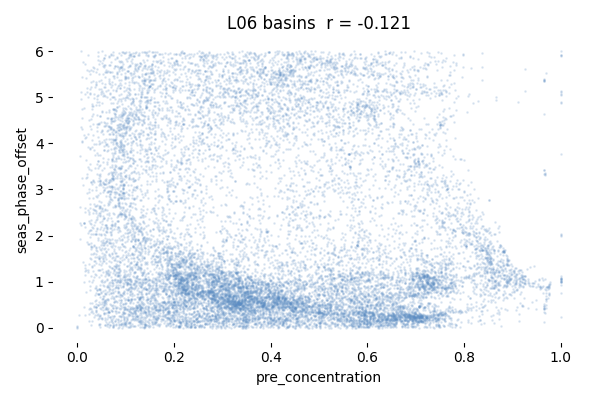

In [7]:
# Cell 7  — A2: Correlation + distance metric selection

valid = basins.dropna(subset=['pre_concentration', 'seas_phase_offset'])
r = np.corrcoef(valid['pre_concentration'], valid['seas_phase_offset'])[0, 1]
print(f'Pearson r(pre_concentration, seas_phase_offset) = {r:.3f}')
print('Mahalanobis warranted if |r| > 0.3; normalized Euclidean adequate otherwise.')

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.scatter(valid['pre_concentration'], valid['seas_phase_offset'],
           s=1, alpha=0.15, color='#5b8dc4')
ax.set_xlabel('pre_concentration', color='black')
ax.set_ylabel('seas_phase_offset', color='black')
ax.set_title(f'L06 basins  r = {r:.3f}', color='black')
ax.tick_params(colors='black')
fig.tight_layout()
fig.savefig(OUT / 'wo7_a2_scatter.png', facecolor='white')
plt.close(fig)
display(IPImage(str(OUT / 'wo7_a2_scatter.png')))

In [8]:
# Cell 8  — A2 (cont.): Build normalized-Euclidean and Mahalanobis distance functions

from numpy.linalg import inv

# 2-index feature matrix (pre_concentration, seas_phase_offset)
IDX2 = ['pre_concentration', 'seas_phase_offset']
X2 = basins[IDX2].to_numpy(dtype=float)   # (N, 2); may contain NaN

# Z-score parameters (from non-NaN rows)
mask = ~np.isnan(X2).any(axis=1)
mu2  = X2[mask].mean(axis=0)
sd2  = X2[mask].std(axis=0)
X2z  = (X2 - mu2) / sd2   # normalized

# Mahalanobis covariance (2×2)
cov2 = np.cov(X2[mask].T)
VI2  = inv(cov2)

def dist_norm_euclidean(q_idx, X):
    """Normalized Euclidean distance from query row q_idx to all rows."""
    diff = X - X[q_idx]
    return np.sqrt((diff ** 2).sum(axis=1))

def dist_mahalanobis(q_idx, X, VI):
    """Mahalanobis distance from query row q_idx to all rows."""
    diff = X - X[q_idx]         # (N, k)
    return np.sqrt(np.einsum('ni,ij,nj->n', diff, VI, diff))

print('Distance functions ready.')
print(f'Z-score params — mean: {mu2}, sd: {sd2}')
print(f'Covariance:\n{cov2.round(4)}')

Distance functions ready.
Z-score params — mean: [0.41193914 1.98691207], sd: [0.23014339 1.84394807]
Covariance:
[[ 0.053  -0.0514]
 [-0.0514  3.4004]]


In [9]:
# Cell 9  — A3: SF validation test
# Find the L06 basin containing San Francisco, rank all basins by similarity.

sf_sql = """
SELECT hybas_id
FROM public.basin06
WHERE ST_Within(ST_SetSRID(ST_MakePoint(-122.42, 37.77), 4326), geom)
LIMIT 1
"""
sf_hybas = pd.read_sql(sf_sql, conn).iloc[0, 0]
sf_idx   = basins.index[basins['hybas_id'] == sf_hybas][0]
sf_row   = basins.loc[sf_idx, IDX2]
print(f'SF basin hybas_id: {sf_hybas}')
print(f'SF indices: pre_concentration={sf_row["pre_concentration"]:.3f}, '
      f'seas_phase_offset={sf_row["seas_phase_offset"]:.3f}')

# Compute both distance metrics (on z-scored feature matrix)
VI2z = inv(np.cov(X2z[mask].T))
d_ne = dist_norm_euclidean(sf_idx, X2z)
d_mh = dist_mahalanobis(sf_idx, X2z, VI2z)

basins['dist_ne'] = d_ne
basins['dist_mh'] = d_mh

# Top-50 by normalized Euclidean, joined to gazetteer
top50 = basins.nsmallest(51, 'dist_ne').iloc[1:]   # exclude self
top50_gaz = top50.merge(
    gaz[['hybas_id','place_name','ccodes']].drop_duplicates('hybas_id'),
    on='hybas_id', how='left'
)
with_place = top50_gaz.dropna(subset=['place_name'])
print(f'\nTop-50 similar basins: {len(with_place)} have a named place')
print(with_place[['dist_ne','pre_concentration','seas_phase_offset',
                   'place_name','ccodes']].head(20).to_string(index=False))

SF basin hybas_id: 7060013180.0
SF indices: pre_concentration=0.604, seas_phase_offset=5.644

Top-50 similar basins: 36 have a named place
 dist_ne  pre_concentration  seas_phase_offset      place_name ccodes
0.018707           0.607080           5.616852        Mirinzal   [BR]
0.026132           0.605234           5.692032     Barkerville   [US]
0.030422           0.600558           5.690808           Icatu   [BR]
0.037120           0.607362           5.579860           Ashur   [IQ]
0.037313           0.611963           5.677757    An-Nāṣirīyah   [IQ]
0.045996           0.593879           5.642600    Mesa Redonda   [MX]
0.046164           0.607553           5.725687       Tell Ajri   [IQ]
0.049515           0.593095           5.637826      Shithāthah   [IQ]
0.058139           0.612087           5.556147         Hassuna   [IQ]
0.058542           0.607749           5.748931          Chipps     []
0.059891           0.613833           5.563254          Cahuil   [CL]
0.060730           0.

In [10]:
# Cell 10  — A3 (cont.): Compare NE vs Mahalanobis top-20 named places

top50_mh = basins.nsmallest(51, 'dist_mh').iloc[1:]
top50_mh_gaz = top50_mh.merge(
    gaz[['hybas_id','place_name','ccodes']].drop_duplicates('hybas_id'),
    on='hybas_id', how='left'
).dropna(subset=['place_name'])

print('=== Normalized Euclidean top-15 named places ===')
print(with_place[['place_name','ccodes','dist_ne',
                   'pre_concentration','seas_phase_offset']].head(15).to_string(index=False))
print()
print('=== Mahalanobis top-15 named places ===')
print(top50_mh_gaz[['place_name','ccodes','dist_mh',
                      'pre_concentration','seas_phase_offset']].head(15).to_string(index=False))

=== Normalized Euclidean top-15 named places ===
     place_name ccodes  dist_ne  pre_concentration  seas_phase_offset
       Mirinzal   [BR] 0.018707           0.607080           5.616852
    Barkerville   [US] 0.026132           0.605234           5.692032
          Icatu   [BR] 0.030422           0.600558           5.690808
          Ashur   [IQ] 0.037120           0.607362           5.579860
   An-Nāṣirīyah   [IQ] 0.037313           0.611963           5.677757
   Mesa Redonda   [MX] 0.045996           0.593879           5.642600
      Tell Ajri   [IQ] 0.046164           0.607553           5.725687
     Shithāthah   [IQ] 0.049515           0.593095           5.637826
        Hassuna   [IQ] 0.058139           0.612087           5.556147
         Chipps     [] 0.058542           0.607749           5.748931
         Cahuil   [CL] 0.059891           0.613833           5.563254
     Choga Mish   [IR] 0.060730           0.590777           5.666957
Whiskey Springs   [US] 0.067951          

In [11]:
# Cell 11  — A4: Distance threshold — what cutoff gives useful results?

# Distribution of NE distances from SF across all basins with a named place
gaz_basins = basins[basins['hybas_id'].isin(gaz['hybas_id'].unique())].copy()
gaz_basins = gaz_basins[gaz_basins['hybas_id'] != sf_hybas]

fig, ax = plt.subplots(figsize=(7, 3))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.hist(gaz_basins['dist_ne'].dropna(), bins=80, color='#5b8dc4', alpha=0.7)
for pct, ls in [(0.05,'--'),(0.10,':')]:
    v = gaz_basins['dist_ne'].quantile(pct)
    ax.axvline(v, color='#c0392b', linestyle=ls, linewidth=1)
    ax.text(v+0.01, ax.get_ylim()[1]*0.85, f'p{int(pct*100)}={v:.2f}',
            color='#c0392b', fontsize=9)
ax.set_xlabel('Normalized Euclidean distance from SF basin', color='black')
ax.set_ylabel('Basin count', color='black')
ax.tick_params(colors='black')
ax.set_title('SF similarity distance distribution (basins with ≥1 named place)', color='black')
fig.tight_layout()
fig.savefig(OUT / 'wo7_a4_threshold.png', facecolor='white')
plt.close(fig)
display(IPImage(str(OUT / 'wo7_a4_threshold.png')))

for p in [5, 10, 20]:
    v = gaz_basins['dist_ne'].quantile(p/100)
    n = (gaz_basins['dist_ne'] <= v).sum()
    print(f'  p{p:02d} cutoff {v:.3f} → {n} basins with a named place')

  p05 cutoff 0.591 → 539 basins with a named place
  p10 cutoff 1.015 → 1078 basins with a named place
  p20 cutoff 1.753 → 2155 basins with a named place


In [12]:
# Cell 12  — A6: fclasses filter — does restricting to P-only help?
# The local table already contains only P|S places (built SQL filters with &&).
# Here we compare P-only (populated places) vs. P+S (adds spots/buildings).
# fclasses from psycopg3 arrives as a Python list, e.g. ['P'] or ['P','S'] —
# use .apply() not .str.contains().

gaz_all = gaz.copy()
gaz_P   = gaz[gaz['fclasses'].apply(lambda x: 'P' in (x or []))].copy()

print(f'Gazetteer rows (P+S fclasses): {len(gaz_all):,}')
print(f'Gazetteer rows (P only):       {len(gaz_P):,}')
print(f'Unique basins covered (P+S):   {gaz_all["hybas_id"].nunique():,}')
print(f'Unique basins covered (P only):{gaz_P["hybas_id"].nunique():,}')

# Top results from SF query: all (P+S) vs. P-only
top50_ne_all = top50.merge(
    gaz_all[['hybas_id','place_name','ccodes']].drop_duplicates('hybas_id'),
    on='hybas_id', how='left'
).dropna(subset=['place_name'])

top50_ne_P = top50.merge(
    gaz_P[['hybas_id','place_name','ccodes']].drop_duplicates('hybas_id'),
    on='hybas_id', how='left'
).dropna(subset=['place_name'])

print('\n=== Top-10 named places (P+S) ===')
print(top50_ne_all[['place_name','ccodes','dist_ne']].head(10).to_string(index=False))
print('\n=== Top-10 named places (P only) ===')
print(top50_ne_P[['place_name','ccodes','dist_ne']].head(10).to_string(index=False))

Gazetteer rows (P+S fclasses): 1,508,492
Gazetteer rows (P only):       1,459,273
Unique basins covered (P+S):   10,799
Unique basins covered (P only):10,681

=== Top-10 named places (P+S) ===
  place_name ccodes  dist_ne
    Mirinzal   [BR] 0.018707
 Barkerville   [US] 0.026132
       Icatu   [BR] 0.030422
       Ashur   [IQ] 0.037120
An-Nāṣirīyah   [IQ] 0.037313
Mesa Redonda   [MX] 0.045996
   Tell Ajri   [IQ] 0.046164
  Shithāthah   [IQ] 0.049515
     Hassuna   [IQ] 0.058139
      Chipps     [] 0.058542

=== Top-10 named places (P only) ===
  place_name ccodes  dist_ne
    Mirinzal   [BR] 0.018707
 Barkerville   [US] 0.026132
       Icatu   [BR] 0.030422
       Ashur   [IQ] 0.037120
An-Nāṣirīyah   [IQ] 0.037313
Mesa Redonda   [MX] 0.045996
   Tell Ajri   [IQ] 0.046164
  Shithāthah   [IQ] 0.049515
     Hassuna   [IQ] 0.058139
      Chipps     [] 0.058542
